In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/yashwanthkumar/Desktop/Desktop/ML project/early_layoff_warning/data/layoffs_data.csv")
df

,Company,Location_HQ,Industry,Laid_Off_Count,Date,Source,Funds_Raised,Stage,Date_Added,Country,Percentage,List_of_Employees_Laid_Off
0,Oda,Oslo,Food,150.0,2024-06-05,https://techcrunch.com/2024/06/05/softbank-bac...,691.0,Unknown,2024-06-05 18:01:25,Norway,NaN,Unknown
1,Pagaya,Tel Aviv,Finance,100.0,2024-06-05,https://www.calcalistech.com/ctechnews/article...,2000.0,Post-IPO,2024-06-05 23:11:24,Israel,0.20,Unknown
2,Aleph Farms,Tel Aviv,Food,30.0,2024-06-05,https://www.calcalistech.com/ctechnews/article...,119.0,Unknown,2024-06-05 23:13:43,Israel,0.30,Unknown
3,MoonPay,Dover,Crypto,30.0,2024-06-05,https://www.theblock.co/post/298638/moonpay-la...,651.0,Unknown,2024-06-05 23:12:47,United States,0.10,Unknown
4,Yext,New York City,Marketing,NaN,2024-06-05,https://www.investing.com/news/economy-news/ye...,117.0,Post-IPO,2024-06-05 18:02:40,United States,0.12,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...
3637,Service,Los Angeles,Travel,NaN,2020-03-16,https://techcrunch.com/2020/03/16/travel-savin...,5.1,Seed,2020-08-31 15:17:26,United States,1.00,Unknown
3638,HopSkipDrive,Los Angeles,Transportation,8.0,2020-03-13,https://layoffs.fyi/2020/04/02/hopskipdrive-la...,45.0,Unknown,2020-04-03 04:47:03,United States,0.10,Unknown
3639,Panda Squad,SF Bay Area,Consumer,6.0,2020-03-13,https://twitter.com/danielsinger/status/123854...,1.0,Seed,2020-04-17 00:12:49,United States,0.75,Unknown
3640,Tamara Mellon,Los Angeles,Retail,20.0,2020-03-12,https://layoffs.fyi/list/tamara-mellon/,90.0,Series C,2020-03-31 16:04:23,United States,0.40,Unknown


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3642 entries, 0 to 3641
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company                     3642 non-null   str    
 1   Location_HQ                 3642 non-null   str    
 2   Industry                    3642 non-null   str    
 3   Laid_Off_Count              2389 non-null   float64
 4   Date                        3642 non-null   str    
 5   Source                      3642 non-null   str    
 6   Funds_Raised                3252 non-null   float64
 7   Stage                       3642 non-null   str    
 8   Date_Added                  3642 non-null   str    
 9   Country                     3642 non-null   str    
 10  Percentage                  2342 non-null   float64
 11  List_of_Employees_Laid_Off  3642 non-null   str    
dtypes: float64(3), str(9)
memory usage: 341.6 KB


In [4]:
df.describe()

,Laid_Off_Count,Funds_Raised,Percentage
count,2389.000000,3252.000000,2342.000000
mean,257.926329,798.569494,0.281216
std,829.432277,4758.393161,0.287294
min,3.000000,0.000000,0.000000
25%,40.000000,51.000000,0.100000
50%,80.000000,166.000000,0.170000
75%,181.000000,469.250000,0.300000
max,14000.000000,121900.000000,1.000000


In [5]:
df.isna().sum()

Company                          0
Location_HQ                      0
Industry                         0
Laid_Off_Count                1253
Date                             0
Source                           0
Funds_Raised                   390
Stage                            0
Date_Added                       0
Country                          0
Percentage                    1300
List_of_Employees_Laid_Off       0
dtype: int64

In [6]:
df['Stage'].value_counts()

Stage
Post-IPO          768
Unknown           618
Series B          429
Series C          405
Series D          316
Acquired          314
Series A          245
Series E          171
Seed              117
Series F          102
Private Equity     63
Series H           33
Series G           23
Subsidiary         21
Series J            9
Series I            8
Name: count, dtype: int64

In [7]:
late_stage = ['Series G', 'Series H', 'Series I', 'Series J', 'Subsidiary']
df["Stage"] = df["Stage"].replace(late_stage, "late_stage")

In [8]:
mask = df["Funds_Raised"] != "Unknown"

df.loc[mask, "Funds_Raised"] = df[mask].groupby("Stage")["Funds_Raised"].transform(lambda x: x.fillna(x.median()))



In [9]:
df.isna().sum()

Company                          0
Location_HQ                      0
Industry                         0
Laid_Off_Count                1253
Date                             0
Source                           0
Funds_Raised                     0
Stage                            0
Date_Added                       0
Country                          0
Percentage                    1300
List_of_Employees_Laid_Off       0
dtype: int64

In [10]:
df.dropna(subset=["Laid_Off_Count"], inplace=True)

In [11]:
df.shape

(2389, 12)

In [12]:
print(df['Industry'].value_counts())
print(df['Country'].value_counts().head(10))
print(df['Date'].min(), df['Date'].max())

Industry
Finance           300
Retail            204
Healthcare        190
Transportation    155
Food              139
Consumer          136
Other             135
Marketing         122
Education          98
Media              91
Real Estate        90
Crypto             83
Security           83
Data               70
Travel             69
HR                 64
Sales              44
Logistics          43
Infrastructure     37
Support            36
Recruiting         36
Hardware           35
Product            32
Fitness            29
Energy             17
Manufacturing      12
Legal              12
Construction       11
Aerospace          10
AI                  5
Unknown             1
Name: count, dtype: int64
Country
United States     1511
India              210
Canada             108
Germany             77
Brazil              74
Israel              70
United Kingdom      70
Australia           42
Singapore           27
Sweden              23
Name: count, dtype: int64
2020-03-11 2024-06-

/var/folders/f7/2q2lm39d6zxblqm5z9mkrm500000gn/T/ipykernel_86196/2657500303.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = industry_counts.values, y = industry_counts.index, ax = axes[0], palette="viridis")
/var/folders/f7/2q2lm39d6zxblqm5z9mkrm500000gn/T/ipykernel_86196/2657500303.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = country_values.values, y = country_values.index, ax = axes[1], palette="viridis")


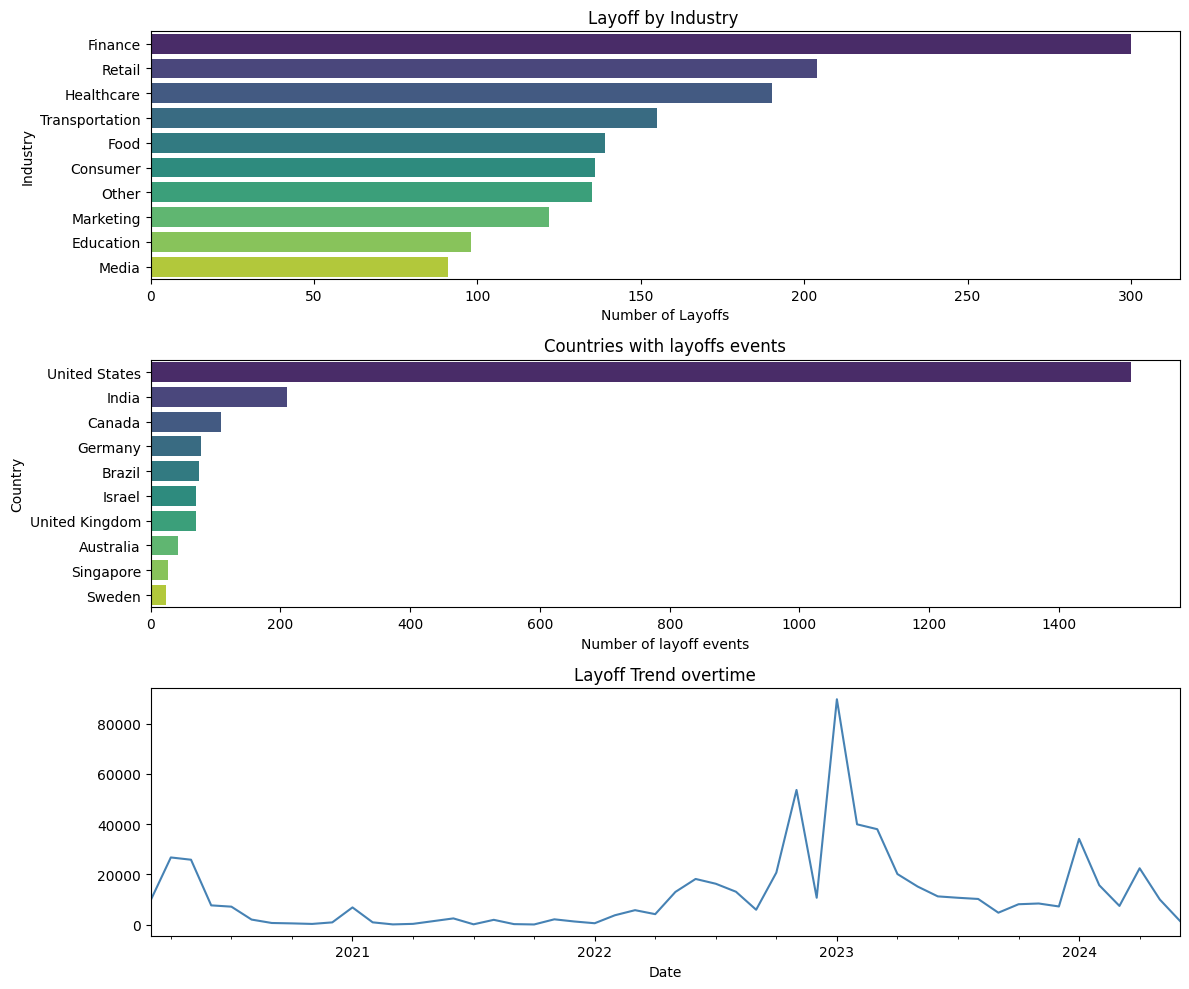

In [13]:
fig, axes = plt.subplots(3,1, figsize = (12,10))

#INDUSTRY WITH MORE LAYOFFS
industry_counts = df["Industry"].value_counts().head(10)

sns.barplot(x = industry_counts.values, y = industry_counts.index, ax = axes[0], palette="viridis")
axes[0].set_title("Layoff by Industry ")
axes[0].set_xlabel("Number of Layoffs")
#COUNTRY WITH MORE OF LAYOFF INDUSTRIES
country_values = df["Country"].value_counts().head(10)

sns.barplot(x = country_values.values, y = country_values.index, ax = axes[1], palette="viridis")
axes[1].set_title("Countries with layoffs events")
axes[1].set_xlabel("Number of layoff events")

#OVERTIME LAYOFF RATE

df["Date"] = pd.to_datetime(df["Date"])
df.groupby(df["Date"].dt.to_period("M"))["Laid_Off_Count"].sum().plot(ax = axes[2], kind = "line", color = "steelblue")
axes[2].set_title("Layoff Trend overtime")

plt.tight_layout()
plt.show()


<Axes: ylabel='Laid_Off_Count'>

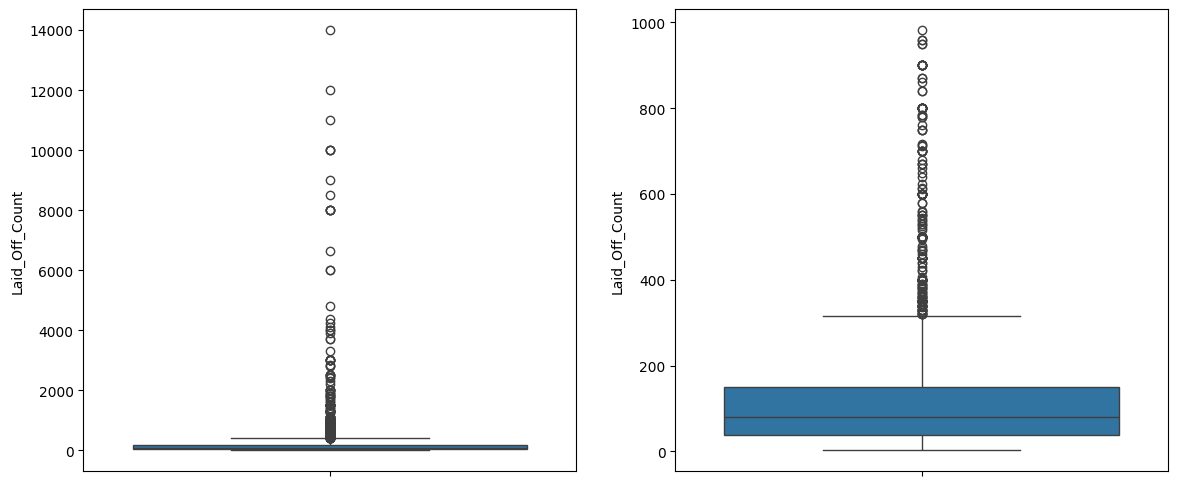

In [14]:
fig, axes = plt.subplots(1,2,figsize = (14,6))

sns.boxplot(y = df["Laid_Off_Count"], ax = axes[0])

sns.boxplot(y = df[df["Laid_Off_Count"] < 1000]["Laid_Off_Count"], ax = axes[1])

In [15]:
Q1 = df['Laid_Off_Count'].quantile(0.25)
Q3 = df['Laid_Off_Count'].quantile(0.75)
IQR = Q3 - Q1

outlier_threshold = Q3 + 1.5 * IQR
outliers = df[df['Laid_Off_Count'] > outlier_threshold]

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Outlier threshold: {outlier_threshold}")
print(f"Number of outlier rows: {len(outliers)}")
print(outliers[['Company', 'Laid_Off_Count', 'Stage', 'Industry']].sort_values('Laid_Off_Count', ascending=False).head(10))

Q1: 40.0, Q3: 181.0, IQR: 141.0
Outlier threshold: 392.5
Number of outlier rows: 279
        Company  Laid_Off_Count     Stage        Industry
80        Tesla         14000.0  Post-IPO  Transportation
1543     Google         12000.0  Post-IPO        Consumer
2027       Meta         11000.0  Post-IPO        Consumer
1576  Microsoft         10000.0  Post-IPO           Other
1218       Meta         10000.0  Post-IPO        Consumer
1959     Amazon         10000.0  Post-IPO          Retail
1201     Amazon          9000.0  Post-IPO          Retail
1288   Ericsson          8500.0  Post-IPO           Other
1718     Amazon          8000.0  Post-IPO          Retail
1076      Flink          8000.0  Series B            Food


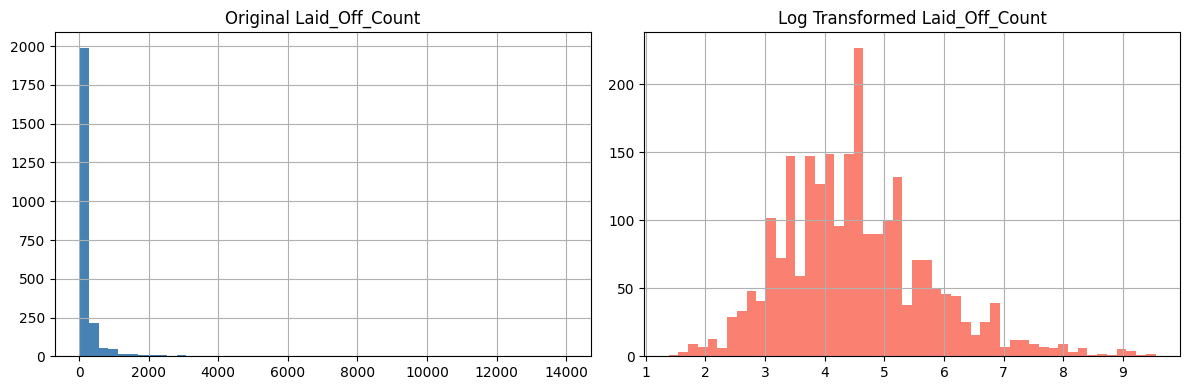

In [16]:
df['Laid_Off_Count_Log'] = np.log1p(df['Laid_Off_Count'])

# Verify it looks better
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Laid_Off_Count'].hist(ax=axes[0], bins=50, color='steelblue')
axes[0].set_title('Original Laid_Off_Count')

df['Laid_Off_Count_Log'].hist(ax=axes[1], bins=50, color='salmon')
axes[1].set_title('Log Transformed Laid_Off_Count')

plt.tight_layout()
plt.show()

In [17]:
df["Stage"].unique()

<StringArray>
[       'Unknown',       'Post-IPO',       'Series B',       'Acquired',
     'late_stage',       'Series F',       'Series D',       'Series E',
       'Series C', 'Private Equity',       'Series A',           'Seed']
Length: 12, dtype: str

In [18]:
filtering = ["Post-IPO", "Acquired", "Private Equity'"]

df_public = df[(df["Country"] == "United States") & (df["Stage"].isin(filtering))].copy()

print(df_public.shape)
print(df_public["Stage"].value_counts())
print(df_public["Company"].nunique())



(577, 13)
Stage
Post-IPO    435
Acquired    142
Name: count, dtype: int64
364


In [19]:
public_companies = df_public["Company"].unique().tolist()

print(f"total unique companies {len(public_companies)}")
print(sorted(public_companies)[:30])

total unique companies 364
['10X Genomics', '23andMe', '8x8', 'AEye', 'Absci', 'Actifio', 'Adaptive Biotechnologies', 'Adobe', 'Affirm', 'Airbnb', 'Akamai', 'Akili Labs', 'Allbirds', 'Alteryx', 'Amazon', 'Amdocs', 'American Robotics', 'Amplitude', 'Analog Devices', 'Anaplan', 'Ancestry', 'AppFolio', 'AppGate', 'AppLovin', 'Appgate', 'Apple', 'Asana', 'Assurance', 'Audible', 'Autodesk']


In [20]:
print(df["Industry"].unique())

<StringArray>
[          'Food',        'Finance',         'Crypto',          'Other',
     'Healthcare',       'Consumer',         'Travel', 'Infrastructure',
          'Sales', 'Transportation',      'Marketing',      'Education',
  'Manufacturing',        'Product',             'HR',         'Energy',
        'Support',        'Fitness',      'Aerospace',         'Retail',
             'AI',      'Logistics',       'Hardware',       'Security',
     'Recruiting',          'Media',    'Real Estate',           'Data',
          'Legal',        'Unknown',   'Construction']
Length: 31, dtype: str


In [21]:
# Known ticker mappings - we'll start with these and expand
ticker_map = {
    '10X Genomics': 'TXG',
    '23andMe': 'ME',
    '8x8': 'EGHT',
    'AEye': 'LIDR',
    'Absci': 'ABSI',
    'Adobe': 'ADBE',
    'Affirm': 'AFRM',
    'Airbnb': 'ABNB',
    'Akamai': 'AKAM',
    'Allbirds': 'BIRD',
    'Alteryx': 'AYX',
    'Amazon': 'AMZN',
    'Amplitude': 'AMPL',
    'Analog Devices': 'ADI',
    'AppFolio': 'APPF',
    'AppLovin': 'APP',
    'Appgate': 'APGT',
    'Apple': 'AAPL',
    'Asana': 'ASAN',
    'Autodesk': 'ADSK',
}

print(f"Manually mapped so far: {len(ticker_map)}")

Manually mapped so far: 20


In [22]:
import yfinance as yf
import time

def find_ticker(company_name):
    try:
        ticker = yf.Search(company_name, max_results=1)
        result = ticker.quotes
        if result:
            return result[0].get('symbol', None)
        return None
    except:
        return None
    
auto_mapped = {}
failed = []

for company in public_companies:
    if company not in ticker_map:
        tick = find_ticker(company)
        if tick:
            auto_mapped[company] = tick
        else:
            failed.append(company)
        time.sleep(0.1)

print(f"Auto mapped: {len(auto_mapped)}")
print(f"Failed to map: {len(failed)}")
print(f"Failed companies: {failed}")

Auto mapped: 190
Failed to map: 154
Failed companies: ['FlightStats', 'Lucid Motors', 'Indeed', 'Vacasa', 'Vivian Health', 'Ancestry', 'Deadspin', 'Turnitin', 'Edgio', 'Instacart', 'Drizly', 'Proofpoint', 'Thinx', 'TechCrunch', 'iRobot', 'Riot Games', 'First Mode', 'Veeam', 'Audible', 'Citrix', 'FreshDirect', 'Instagram', 'Twitch', 'Nevro', 'NanoString Technologies', 'Invitae', 'ForgeRock', 'Zulily', 'TuSimple', 'VMware', 'NextGen Healthcare', 'Sarcos', 'Informatica', 'Splunk', 'Hippo Insurance', 'Bullhorn', 'LinkedIn', 'Kayak / OpenTable', 'Bandcamp', 'Lending Club', 'MariaDB', 'Juniper Networks', 'SchoolMint', 'Qualtrics', 'Lululemon Studio', 'Merative', 'Sage Therapeutics copy', 'ForeScout', 'SecureWorks', 'Shutterfly', 'Dealtale', 'Thoughtworks', 'Inspirato', 'PayScale', 'Matterport', 'Ludia', 'New Relic', 'Anaplan', 'TrueCar', 'Grubhub', 'Sumo Logic', 'Flatiron Health', 'Zendesk', 'WillowTree', 'Cerner', 'Stack Overflow', 'Sonatype', 'Brightcove', 'Zymergen', 'Poppulo', 'Red Hat',

In [23]:
# These failed but have known tickers or parent company tickers
manual_additions = {
    # Acquired - use parent company ticker
    'Instagram': 'META',      # owned by Meta
    'Twitch': 'AMZN',         # owned by Amazon
    'Audible': 'AMZN',        # owned by Amazon
    'LinkedIn': 'MSFT',       # owned by Microsoft
    'Waze': 'GOOGL',          # owned by Google
    'YouTube': 'GOOGL',       # owned by Google
    
    # Went private but were public - still have historical data
    'VMware': 'VMW',
    'Citrix': 'CTXS',
    'Qualtrics': 'XM',
    'Zendesk': 'ZEN',
    'Splunk': 'SPLK',
    'Anaplan': 'PLAN',
    'Medallia': 'MDLA',
    'Smartsheet': 'SMAR',
    'New Relic': 'NEWR',
    'Informatica': 'INFA',
    'Matterport': 'MTTR',
    'Redfin': 'RDFN',
    'Eventbrite': 'EB',
    'Leafly': 'LFLY',
    'Instacart': 'CART',
    'Vacasa': 'VCSA',
    'Confluent': 'CFLT',
    'HashiCorp': 'HCP',
    'Lucid Motors': 'LCID',
    'Canoo': 'GOEV',
    'Proterra': 'PTRA',
    'TuSimple': 'TSP',
    'Embark Trucks': 'EMBK',
    'Velodyne Lidar': 'VLDR',
    'Grubhub': 'GRUB',
    'Lending Club': 'LC',
    'TrueCar': 'TRUE',
    'Brightcove': 'BCOV',
    'Sumo Logic': 'SUMO',
    'Thoughtworks': 'TWKS',
    'Inspirato': 'ISPO',
    'WalkMe': 'WKME',
    'Pear Therapeutics': 'PEAR',
    'Root Insurance': 'ROOT',
    'Metromile': 'MILE',
    'IronNet': 'IRNT',
    'Integral Ad Science': 'IAS',
    'EverBridge': 'EVBG',
    'Momentive': 'MNTV',
    'UserTesting': 'USER',
    'Hippo Insurance': 'HIPO',
    'Nevro': 'NVRO',
    'Science 37': 'SNCE',
    'Sage Therapeutics': 'SAGE',
    'SecureWorks': 'SCWX',
    'Invitae': 'NVTA',
    'MariaDB': 'MRDB',
    'Weedmaps': 'MAPS',
    'NanoString Technologies': 'NSTG',
    'Quanergy Systems': 'QNGY',
    'Rubius': 'RUBY',
    'Tufin': 'TUFN',
    'ForgeRock': 'FORG',
    'NextGen Healthcare': 'NXGN',
    'Cerner': 'CERN',
}


In [24]:
all_mapping = {**ticker_map, **auto_mapped, **manual_additions}

print(f"Total mapped: {len(all_mapping)} out of {len(public_companies)}")

Total mapped: 270 out of 364


In [25]:
df_mapped = pd.DataFrame(list(all_mapping.items()), columns = ["Company", "ticker"])

df_mapped.to_csv("/Users/yashwanthkumar/Desktop/Desktop/ML project/early_layoff_warning/data/ticker_mapping.csv", index = False)

print(df_mapped.head(10))

        Company ticker
0  10X Genomics    TXG
1       23andMe     ME
2           8x8   EGHT
3          AEye   LIDR
4         Absci   ABSI
5         Adobe   ADBE
6        Affirm   AFRM
7        Airbnb   ABNB
8        Akamai   AKAM
9      Allbirds   BIRD


In [26]:
df_copy = df.copy()

df_merged = df_copy.merge(df_mapped, on = "Company", how="left")

print(f"Total rows: {df_copy.shape[0]}")
print(f"Rows with ticker (public): {df_merged['ticker'].notna().sum()}")
print(f"Rows without ticker (private): {df_merged['ticker'].isna().sum()}")

Total rows: 2389
Rows with ticker (public): 480
Rows without ticker (private): 1909


In [27]:
df_merged[df_merged['ticker'].notna()]

,Company,Location_HQ,Industry,Laid_Off_Count,Date,Source,Funds_Raised,Stage,Date_Added,Country,Percentage,List_of_Employees_Laid_Off,Laid_Off_Count_Log,ticker
4,Microsoft,Seattle,Other,1000.0,2024-06-03,https://www.theverge.com/2024/6/3/24170902/mic...,1.0,Post-IPO,2024-06-03 20:27:12,United States,NaN,Unknown,6.908755,MSFT
6,Google,SF Bay Area,Consumer,100.0,2024-05-31,https://www.businessinsider.com/google-cloud-l...,26.0,Post-IPO,2024-06-01 18:35:17,United States,NaN,Unknown,4.615121,GOOG
11,Lucid Motors,SF Bay Area,Transportation,400.0,2024-05-24,https://electrek.co/2024/05/24/lucid-lcid-cuts...,8300.0,Post-IPO,2024-05-24 15:47:21,United States,0.06,Unknown,5.993961,LCID
14,Cue Health,San Diego,Healthcare,180.0,2024-05-22,https://www.fiercebiotech.com/medtech/home-cov...,899.0,Post-IPO,2024-05-23 04:11:46,United States,1.00,Unknown,5.198497,HLTHQ
22,Rivian,Los Angeles,Transportation,120.0,2024-05-10,https://www.sfchronicle.com/tech/article/tech-...,10700.0,Post-IPO,2024-05-11 14:40:18,United States,NaN,Unknown,4.795791,RIVN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2361,Sonder,SF Bay Area,Travel,400.0,2020-03-24,https://layoffs.fyi/2020/03/27/sonder-lays-off...,359.0,Series D,2020-03-28 20:52:49,United States,0.33,Unknown,5.993961,SOND.SW
2366,Compass,New York City,Real Estate,375.0,2020-03-23,https://layoffs.fyi/2020/04/14/compass-laid-of...,1600.0,late_stage,2020-03-28 20:52:49,United States,0.15,Unknown,5.929589,CMPS
2368,Leafly,Seattle,Retail,91.0,2020-03-23,https://www.geekwire.com/2020/leafly-lays-off-...,2.0,Acquired,2020-03-28 20:52:49,United States,0.50,Unknown,4.521789,LFLY
2370,Drip,Salt Lake City,Marketing,20.0,2020-03-23,LinkedIn,0.0,Acquired,2020-04-01 21:32:19,United States,NaN,Unknown,3.044522,DRIP


In [28]:
public_tickers = df_merged[df_merged['ticker'].notna()]['ticker'].unique().tolist()
print(f'public ticker : {public_tickers}')

public ticker : ['MSFT', 'GOOG', 'LCID', 'HLTHQ', 'RIVN', 'VCSA', 'ENVX', 'LRGR', 'CXM', 'BKKT', 'PTON', 'NIACL.NS', 'TSLA', 'TTWO', 'PEANUT33916-USD', 'INTC', 'AAPL', 'DELL', 'EA', 'BMBL', 'EXPE', 'AFRM', 'TOST', 'SOND.SW', 'CSCO', 'CART', 'PI', 'RSKD', 'SIRI', '6PU.DU', 'DOCU', 'AMZN', 'SNAP', 'OKTA', 'ZM', 'ILMN', 'PYPL', 'XYZ', 'CRM', 'EBAY', 'VRM', 'GOTO.JK', 'W', 'GOOGL', 'NET', 'CTXS', 'IAC', 'META', 'NVRO', 'RENT', 'U', 'SMR', 'NSTG', 'XRX', 'ENPH', 'NCLH', 'NVTA', 'ETSY', 'ADI', 'FORG', 'CHAT', 'TSP', 'VMW', 'NXGN', 'CHWY', 'TRIP', 'CFIBODCL-E.SN', 'Z', 'FFIV', 'VSAT', 'BYND', 'INFA', 'SPLK', 'HIPO', 'LZ', 'QCOM', 'LC', 'MRDB', 'SFIX', 'XM', 'RBLX', 'DRIFT31278-USD', 'ROKU', 'ABSI', 'PEGA', 'ZBRA', 'B2LN34.SA', 'APPF', 'SCWX', 'JBBSX', 'TWKS', 'RPD', 'DOCS', 'ME', 'PL', '1465.TW', 'ISPO', 'TMPOQ', 'CRGO', 'MTTR', 'EVER.MX', 'AOS.F', 'NEWR', 'PAYO', 'HOOD', 'PLAN', 'UBER', 'NIKO-USD', 'SONO', 'TRUE', 'OLOX', 'WDC', 'GRUB', 'CHGG.MX', 'SUMO', 'COHR', 'GTM', '852.SG', 'ZEN', 'ZIP

In [29]:

financial_records = []

for ticker in public_tickers:
    try:
        stock = yf.Ticker(ticker)
        
        # Quarterly financials
        financials = stock.quarterly_financials
        balance_sheet = stock.quarterly_balance_sheet
        info = stock.info
        
        if financials.empty:
            print(f"⚠️ No financials for {ticker}")
            continue
        
        # Loop through each quarter available
        for date in financials.columns:
            record = {
                'Ticker': ticker,
                'Quarter': date,
            }
            
            # Revenue
            if 'Total Revenue' in financials.index:
                record['Revenue'] = financials.loc['Total Revenue', date]
            else:
                record['Revenue'] = None
                
            # Net Income → for profit margin
            if 'Net Income' in financials.index:
                record['Net_Income'] = financials.loc['Net Income', date]
            else:
                record['Net_Income'] = None
                
            # Cash reserves
            if 'Cash And Cash Equivalents' in balance_sheet.index:
                record['Cash_Reserves'] = balance_sheet.loc['Cash And Cash Equivalents', date]
            else:
                record['Cash_Reserves'] = None
            
            # Employee count (same for all quarters, from info)
            record['Employee_Count'] = info.get('fullTimeEmployees', None)
            
            financial_records.append(record)
            
        print(f"✅ {ticker} → {len(financials.columns)} quarters")
        time.sleep(0.1)
        
    except Exception as e:
        print(f"❌ {ticker} failed: {e}")
        continue

# Convert to dataframe
df_financials = pd.DataFrame(financial_records)
print(f"\nTotal financial records: {df_financials.shape}")
print(df_financials.head())

✅ MSFT → 5 quarters
✅ GOOG → 6 quarters
✅ LCID → 7 quarters
⚠️ No financials for HLTHQ
✅ RIVN → 5 quarters
⚠️ No financials for VCSA
❌ ENVX failed: Timestamp('2024-09-30 00:00:00')
⚠️ No financials for LRGR
✅ CXM → 6 quarters
✅ BKKT → 7 quarters
❌ PTON failed: Timestamp('2024-12-31 00:00:00')
❌ NIACL.NS failed: Timestamp('2025-12-31 00:00:00')
✅ TSLA → 7 quarters
✅ TTWO → 7 quarters
⚠️ No financials for PEANUT33916-USD
✅ INTC → 5 quarters
✅ AAPL → 5 quarters
✅ DELL → 6 quarters
❌ EA failed: Timestamp('2024-12-31 00:00:00')
✅ BMBL → 6 quarters
✅ EXPE → 7 quarters
✅ AFRM → 5 quarters
✅ TOST → 7 quarters
⚠️ No financials for SOND.SW
✅ CSCO → 5 quarters
✅ CART → 6 quarters
✅ PI → 6 quarters
✅ RSKD → 6 quarters
✅ SIRI → 7 quarters
❌ 6PU.DU failed: Timestamp('2026-04-30 00:00:00')
❌ DOCU failed: Timestamp('2024-10-31 00:00:00')
✅ AMZN → 5 quarters
✅ SNAP → 5 quarters
❌ OKTA failed: Timestamp('2026-04-30 00:00:00')
✅ ZM → 5 quarters
❌ ILMN failed: Timestamp('2024-09-30 00:00:00')
✅ PYPL → 5 q

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: INFA"}}}


⚠️ No financials for INFA
⚠️ No financials for SPLK
❌ HIPO failed: Timestamp('2024-09-30 00:00:00')
✅ LZ → 5 quarters
✅ QCOM → 7 quarters
✅ LC → 5 quarters
⚠️ No financials for MRDB
✅ SFIX → 5 quarters
⚠️ No financials for XM
✅ RBLX → 6 quarters
⚠️ No financials for DRIFT31278-USD
✅ ROKU → 5 quarters
✅ ABSI → 7 quarters
✅ PEGA → 6 quarters
✅ ZBRA → 6 quarters
❌ B2LN34.SA failed: Timestamp('2024-09-30 00:00:00')
✅ APPF → 6 quarters
⚠️ No financials for SCWX
⚠️ No financials for JBBSX
⚠️ No financials for TWKS
✅ RPD → 7 quarters
❌ DOCS failed: Timestamp('2024-12-31 00:00:00')


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ME"}}}


⚠️ No financials for ME
❌ PL failed: Timestamp('2024-10-31 00:00:00')
❌ 1465.TW failed: Timestamp('2024-09-30 00:00:00')
⚠️ No financials for ISPO
⚠️ No financials for TMPOQ
✅ CRGO → 7 quarters
⚠️ No financials for MTTR
✅ EVER.MX → 7 quarters
✅ AOS.F → 7 quarters
⚠️ No financials for NEWR
✅ PAYO → 7 quarters
✅ HOOD → 7 quarters
⚠️ No financials for PLAN
✅ UBER → 5 quarters
⚠️ No financials for NIKO-USD
✅ SONO → 5 quarters


...

⚠️ No financials for EB
✅ PLTR → 5 quarters
⚠️ No financials for VLDR
⚠️ No financials for MDLA
✅ EVGO → 5 quarters
✅ 6VY.F → 5 quarters
✅ MU → 5 quarters
✅ 6RR.F → 7 quarters
⚠️ No financials for SMAR
✅ DOCN → 7 quarters
❌ BNK.F failed: Timestamp('2024-09-30 00:00:00')
✅ TWLO → 7 quarters
❌ YOJ.SG failed: Timestamp('2025-06-30 00:00:00')
✅ GTLB → 6 quarters
✅ BARK → 5 quarters
✅ GDDY → 7 quarters
❌ ADSK failed: Timestamp('2026-04-30 00:00:00')
✅ PINS → 5 quarters
❌ DKNG failed: Timestamp('2024-09-30 00:00:00')
⚠️ No financials for CYRNQ
⚠️ No financials for APGT
❌ NTAP failed: Timestamp('2026-04-30 00:00:00')
✅ WDAY → 6 quarters
✅ HUBS → 5 quarters
✅ UPST → 7 quarters
✅ GRPN → 7 quarters
❌ SNPS failed: Timestamp('2025-01-31 00:00:00')


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CFLT"}}}


⚠️ No financials for CFLT
✅ IBM → 5 quarters
❌ LRCX failed: Timestamp('2024-12-31 00:00:00')
✅ GH → 5 quarters
⚠️ No financials for BTTOLD-EUR
❌ COF failed: Timestamp('2024-09-30 00:00:00')
⚠️ No financials for PTRA
❌ WEWORK.BO failed: Timestamp('2025-12-31 00:00:00')
❌ LAW failed: Timestamp('2024-12-31 00:00:00')
✅ TDOC → 5 quarters
✅ EGHT → 6 quarters
✅ NCNO → 5 quarters
⚠️ No financials for SSEAR
✅ RNG → 5 quarters
✅ DH → 5 quarters
⚠️ No financials for HCP
⚠️ No financials for 0P0001MHNW
✅ COIN → 7 quarters
✅ FATE → 5 quarters
✅ CUE → 7 quarters
✅ SOUN → 6 quarters
✅ KLTR → 6 quarters
✅ BI1.DU → 7 quarters
⚠️ No financials for QNGY
✅ DSP → 7 quarters
❌ EFT0.F failed: Timestamp('2024-09-30 00:00:00')
✅ IAS → 5 quarters
✅ CWXZF → 7 quarters
✅ MAPS → 7 quarters
✅ ADBE → 6 quarters
✅ SBIG → 7 quarters
✅ DASH → 5 quarters
✅ CVNA → 7 quarters
❌ PATH failed: Timestamp('2026-04-30 00:00:00')
✅ ASAN → 5 quarters
⚠️ No financials for HOOK-USD
✅ CDLX → 7 quarters
✅ ROOT → 5 quarters
⚠️ No fin

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: GOEV"}}}


⚠️ No financials for GOEV
❌ 300020.SZ failed: Timestamp('2025-09-30 00:00:00')
✅ APP → 6 quarters
⚠️ No financials for IRNT
✅ SKLZ → 7 quarters
✅ B39.F → 6 quarters
❌ ADPT failed: Timestamp('2024-09-30 00:00:00')
❌ YELP failed: Timestamp('2024-09-30 00:00:00')
⚠️ No financials for FCH.L
✅ ISRG → 6 quarters
❌ STUB failed: Timestamp('2024-09-30 00:00:00')
✅ 002273.SZ → 5 quarters
⚠️ No financials for 0P0001DERO.F
⚠️ No financials for RUBI
⚠️ No financials for CSPR-USD
✅ CARG → 7 quarters
✅ GPRO → 5 quarters
✅ DOMO → 6 quarters
⚠️ No financials for SAGE
⚠️ No financials for MIG5.L
⚠️ No financials for DRIP

Total financial records: (1057, 6)
  Ticker    Quarter       Revenue    Net_Income  Cash_Reserves  Employee_Count
0   MSFT 2026-03-31  8.288600e+10  3.177800e+10   3.210500e+10        228000.0
1   MSFT 2025-12-31  8.127300e+10  3.845800e+10   2.429600e+10        228000.0
2   MSFT 2025-09-30  7.767300e+10  2.774700e+10   2.884900e+10        228000.0
3   MSFT 2025-06-30  7.644100e+10  2.

In [30]:
df_financials = df_financials.sort_values(by = ["Ticker", "Quarter"])

df_financials["Profit_margin"] = df_financials["Net_Income"] / df_financials["Revenue"]

df_financials["Revenue_growth"] = df_financials.groupby("Ticker")["Revenue"].pct_change()

df_financials.drop(columns=["Revenue", "Net_Income"])

print(df_financials.shape)
print(df_financials.head(10))
print(df_financials.isnull().sum())

(1057, 8)
         Ticker    Quarter       Revenue    Net_Income  Cash_Reserves  \
1038  002273.SZ 2024-12-31  1.567964e+09  1.683109e+08   2.061991e+09   
1037  002273.SZ 2025-03-31  1.482423e+09  2.208559e+08   1.458024e+09   
1036  002273.SZ 2025-06-30  1.538036e+09  2.798227e+08   1.254594e+09   
1035  002273.SZ 2025-12-31  1.805286e+09  1.891102e+08   1.330422e+09   
1034  002273.SZ 2026-03-31  1.720744e+09  2.466761e+08   1.275932e+09   
610   005930.KS 2024-09-30           NaN           NaN            NaN   
609   005930.KS 2025-03-31  7.914050e+13  8.028407e+12   5.316100e+13   
608   005930.KS 2025-06-30  7.456632e+13  4.934034e+12   4.712002e+13   
607   005930.KS 2025-09-30  8.606175e+13  1.200646e+13   5.339948e+13   
606   005930.KS 2025-12-31  9.383737e+13  1.929205e+13   5.785638e+13   

      Employee_Count  Profit_margin  Revenue_growth  
1038          8721.0       0.107344             NaN  
1037          8721.0       0.148983       -0.054555  
1036          8721.0    

In [31]:
df_financials.to_csv("/Users/yashwanthkumar/Desktop/Desktop/ML project/early_layoff_warning/data/financials.csv", index = False)

In [35]:
print(df_merged.columns.tolist())

['Company', 'Location_HQ', 'Industry', 'Laid_Off_Count', 'Date', 'Source', 'Funds_Raised', 'Stage', 'Date_Added', 'Country', 'Percentage', 'List_of_Employees_Laid_Off', 'Laid_Off_Count_Log', 'ticker']


In [36]:
# Convert dates to datetime first
df_merged['Date'] = pd.to_datetime(df_merged['Date'])
df_financials['Quarter'] = pd.to_datetime(df_financials['Quarter'])

# Function to find the closest quarter BEFORE the layoff date
def get_previous_quarter_financials(row, df_fin):
    if pd.isna(row['ticker']):   # lowercase
        return pd.Series({
            'Cash_Reserves': None,
            'Employee_Count': None,
            'Profit_Margin': None,
            'Revenue_Growth': None
        })
    
    # Get financials for this ticker
    ticker_fin = df_fin[df_fin['Ticker'] == row['ticker']]  # df_fin has capital T
    
    # Find quarters BEFORE the layoff date
    before = ticker_fin[ticker_fin['Quarter'] < row['Date']]
    
    if before.empty:
        return pd.Series({
            'Cash_Reserves': None,
            'Employee_Count': None,
            'Profit_Margin': None,
            'Revenue_Growth': None
        })
    
    # Take the most recent quarter before layoff
    closest = before.sort_values('Quarter').iloc[-1]
    
    return pd.Series({
        'Cash_Reserves': closest['Cash_Reserves'],
        'Employee_Count': closest['Employee_Count'],
        'Profit_Margin': closest['Profit_margin'],
        'Revenue_Growth': closest['Revenue_growth']
    })

# Now run the merge
print("Merging financials... this will take a minute")
financial_cols = df_merged.apply(
    lambda row: get_previous_quarter_financials(row, df_financials), 
    axis=1
)

df_merged = pd.concat([df_merged, financial_cols], axis=1)

print(f"Shape after merge: {df_merged.shape}")
print(df_merged[['Company', 'ticker', 'Date', 'Cash_Reserves', 'Profit_Margin', 'Revenue_Growth']].head(10))

Merging financials... this will take a minute
Shape after merge: (2389, 18)
       Company ticker       Date Cash_Reserves Profit_Margin Revenue_Growth
0          Oda    NaN 2024-06-05          None          None           None
1       Pagaya    NaN 2024-06-05          None          None           None
2  Aleph Farms    NaN 2024-06-05          None          None           None
3      MoonPay    NaN 2024-06-05          None          None           None
4    Microsoft   MSFT 2024-06-03          None          None           None
5        OrCam    NaN 2024-06-03          None          None           None
6       Google   GOOG 2024-05-31          None          None           None
7       Tropic    NaN 2024-05-31          None          None           None
8  FlightStats    NaN 2024-05-30          None          None           None
9        ICANN    NaN 2024-05-30          None          None           None


In [37]:
# See what quarters we have for MSFT
print(df_financials[df_financials['Ticker'] == 'MSFT'][['Ticker', 'Quarter']])

# See what date Microsoft's layoff row has
print(df_merged[df_merged['ticker'] == 'MSFT'][['Company', 'ticker', 'Date']])

  Ticker    Quarter
4   MSFT 2025-03-31
3   MSFT 2025-06-30
2   MSFT 2025-09-30
1   MSFT 2025-12-31
0   MSFT 2026-03-31
        Company ticker       Date
4     Microsoft   MSFT 2024-06-03
155   Microsoft   MSFT 2024-01-25
300    LinkedIn   MSFT 2023-10-16
449   Microsoft   MSFT 2023-07-18
583   Microsoft   MSFT 2023-05-10
590    LinkedIn   MSFT 2023-05-08
965   Microsoft   MSFT 2023-01-18
1950   LinkedIn   MSFT 2020-07-21


In [38]:
# Test with MSFT to see how far back we can go
import yfinance as yf

stock = yf.Ticker('MSFT')

# This gives ALL historical quarterly financials
financials = stock.quarterly_financials
balance = stock.quarterly_balance_sheet

print("Financials date range:")
print(financials.columns.tolist())

print("\nBalance sheet date range:")
print(balance.columns.tolist())

Financials date range:
[Timestamp('2026-03-31 00:00:00'), Timestamp('2025-12-31 00:00:00'), Timestamp('2025-09-30 00:00:00'), Timestamp('2025-06-30 00:00:00'), Timestamp('2025-03-31 00:00:00')]

Balance sheet date range:
[Timestamp('2026-03-31 00:00:00'), Timestamp('2025-12-31 00:00:00'), Timestamp('2025-09-30 00:00:00'), Timestamp('2025-06-30 00:00:00'), Timestamp('2025-03-31 00:00:00'), Timestamp('2024-12-31 00:00:00'), Timestamp('2024-09-30 00:00:00')]


In [39]:
df_recent = df_merged[df_merged['Date'] >= '2024-01-01']
print(df_recent.shape)
print(df_recent['ticker'].notna().sum())  # how many have tickers

(219, 18)
68


In [40]:
# Check what dataframes exist in memory
print("df shape:", df.shape)
print("df columns:", df.columns.tolist())
print("---")
print("df_merged shape:", df_merged.shape)
print("df_merged columns:", df_merged.columns.tolist())

df shape: (2389, 13)
df columns: ['Company', 'Location_HQ', 'Industry', 'Laid_Off_Count', 'Date', 'Source', 'Funds_Raised', 'Stage', 'Date_Added', 'Country', 'Percentage', 'List_of_Employees_Laid_Off', 'Laid_Off_Count_Log']
---
df_merged shape: (2389, 18)
df_merged columns: ['Company', 'Location_HQ', 'Industry', 'Laid_Off_Count', 'Date', 'Source', 'Funds_Raised', 'Stage', 'Date_Added', 'Country', 'Percentage', 'List_of_Employees_Laid_Off', 'Laid_Off_Count_Log', 'ticker', 'Cash_Reserves', 'Employee_Count', 'Profit_Margin', 'Revenue_Growth']


In [41]:
df.to_csv('/Users/yashwanthkumar/Desktop/Desktop/ML project/early_layoff_warning/data/layoffs_cleaned.csv', index=False)
print("Saved layoffs_cleaned.csv")


Saved layoffs_cleaned.csv


In [ ]:
import simfin as sf
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv('SIMFIN_API_KEY')
print(f"Key loaded: {api_key[:4]}...")

sf.set_api_key(api_key)
sf.set_data_dir('../data/simfin/')

# Test - load quarterly income statements
df_income = sf.load_income(variant='quarterly', market='us')
print(df_income.shape)
print(df_income.head())

Key loaded: cd0a...
Dataset "us-income-quarterly" not on disk.
- Downloading ... 100.0%
- Extracting zip-file ... Done!
- Loading from disk ... Done!
(47760, 26)
                    SimFinId Currency  Fiscal Year Fiscal Period Publish Date  \
Ticker Report Date                                                              
A      2020-07-31      45846      USD         2020            Q3   2020-09-01   
       2020-10-31      45846      USD         2020            Q4   2020-12-18   
       2021-01-31      45846      USD         2021            Q1   2021-03-02   
       2021-04-30      45846      USD         2021            Q2   2021-06-01   
       2021-07-31      45846      USD         2021            Q3   2021-09-01   

                   Restated Date  Shares (Basic)  Shares (Diluted)  \
Ticker Report Date                                                   
A      2020-07-31     2021-09-01     309000000.0       312000000.0   
       2020-10-31     2021-09-01     308000000.0       31100

In [44]:
# Check date range
print("Earliest date:", df_income.index.get_level_values('Report Date').min())
print("Latest date:", df_income.index.get_level_values('Report Date').max())

# Check columns
print("\nColumns:", df_income.columns.tolist())

Earliest date: 2020-07-31 00:00:00
Latest date: 2025-05-31 00:00:00

Columns: ['SimFinId', 'Currency', 'Fiscal Year', 'Fiscal Period', 'Publish Date', 'Restated Date', 'Shares (Basic)', 'Shares (Diluted)', 'Revenue', 'Cost of Revenue', 'Gross Profit', 'Operating Expenses', 'Selling, General & Administrative', 'Research & Development', 'Depreciation & Amortization', 'Operating Income (Loss)', 'Non-Operating Income (Loss)', 'Interest Expense, Net', 'Pretax Income (Loss), Adj.', 'Abnormal Gains (Losses)', 'Pretax Income (Loss)', 'Income Tax (Expense) Benefit, Net', 'Income (Loss) from Continuing Operations', 'Net Extraordinary Gains (Losses)', 'Net Income', 'Net Income (Common)']
